In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

from pathlib import Path

from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, roc_auc_score

In [ ]:
base_artifacts = Path.cwd().resolve().parents[1] / 'CausalI2I_artifacts'
figures_path = base_artifacts / 'Figures' / 'sequels'
raw_results = pd.read_csv(base_artifacts / 'Datasets' / 'Sequels' / 'sequels_evaluated.csv')

In [3]:
new_names = {
    'ATE_STABILIZED': 'ATE (stabilized)',
    'cosine_similarity': 'Cosine',
    'correlation': 'Pearson',
    'diff_of_conditionals': 'DoC',
    'jacard_index': 'Jaccard',
    'causal_link': 'causal_effect',
}
raw_results = raw_results.rename(columns=new_names)

standardize = lambda row, col1, col2: row[col1] / np.max([row[col2], 1e-8])
new_cols = {
    "STE": ("ATE", "STD"),
    "ABLT/STD": ("ATE_ABLT", "STD_ABLT"),
    "STE (stabilized)": ("ATE (stabilized)", "STD_STABILIZED")
}
for new_col in new_cols:
    col1, col2 = new_cols[new_col]
    raw_results[new_col] = raw_results.apply(standardize, axis=1, args=(col1, col2))

baselines = ["ATE", "STE", "Pearson", "DoC", "ATE_ABLT", "ABLT/STD", "Cosine", "Jaccard", "ATE (stabilized)", "STE (stabilized)"]

auxiliary = True

In [4]:
cmap = plt.get_cmap("tab10")
color_map = {}
for i, col in enumerate(baselines):
    base_color = cmap(i % 10)
    if i < 10:
        color_map[col] = base_color
    else:
        c = mcolors.to_rgb(base_color)
        color_map[col] = tuple(min(1, x * 1.4) for x in c)

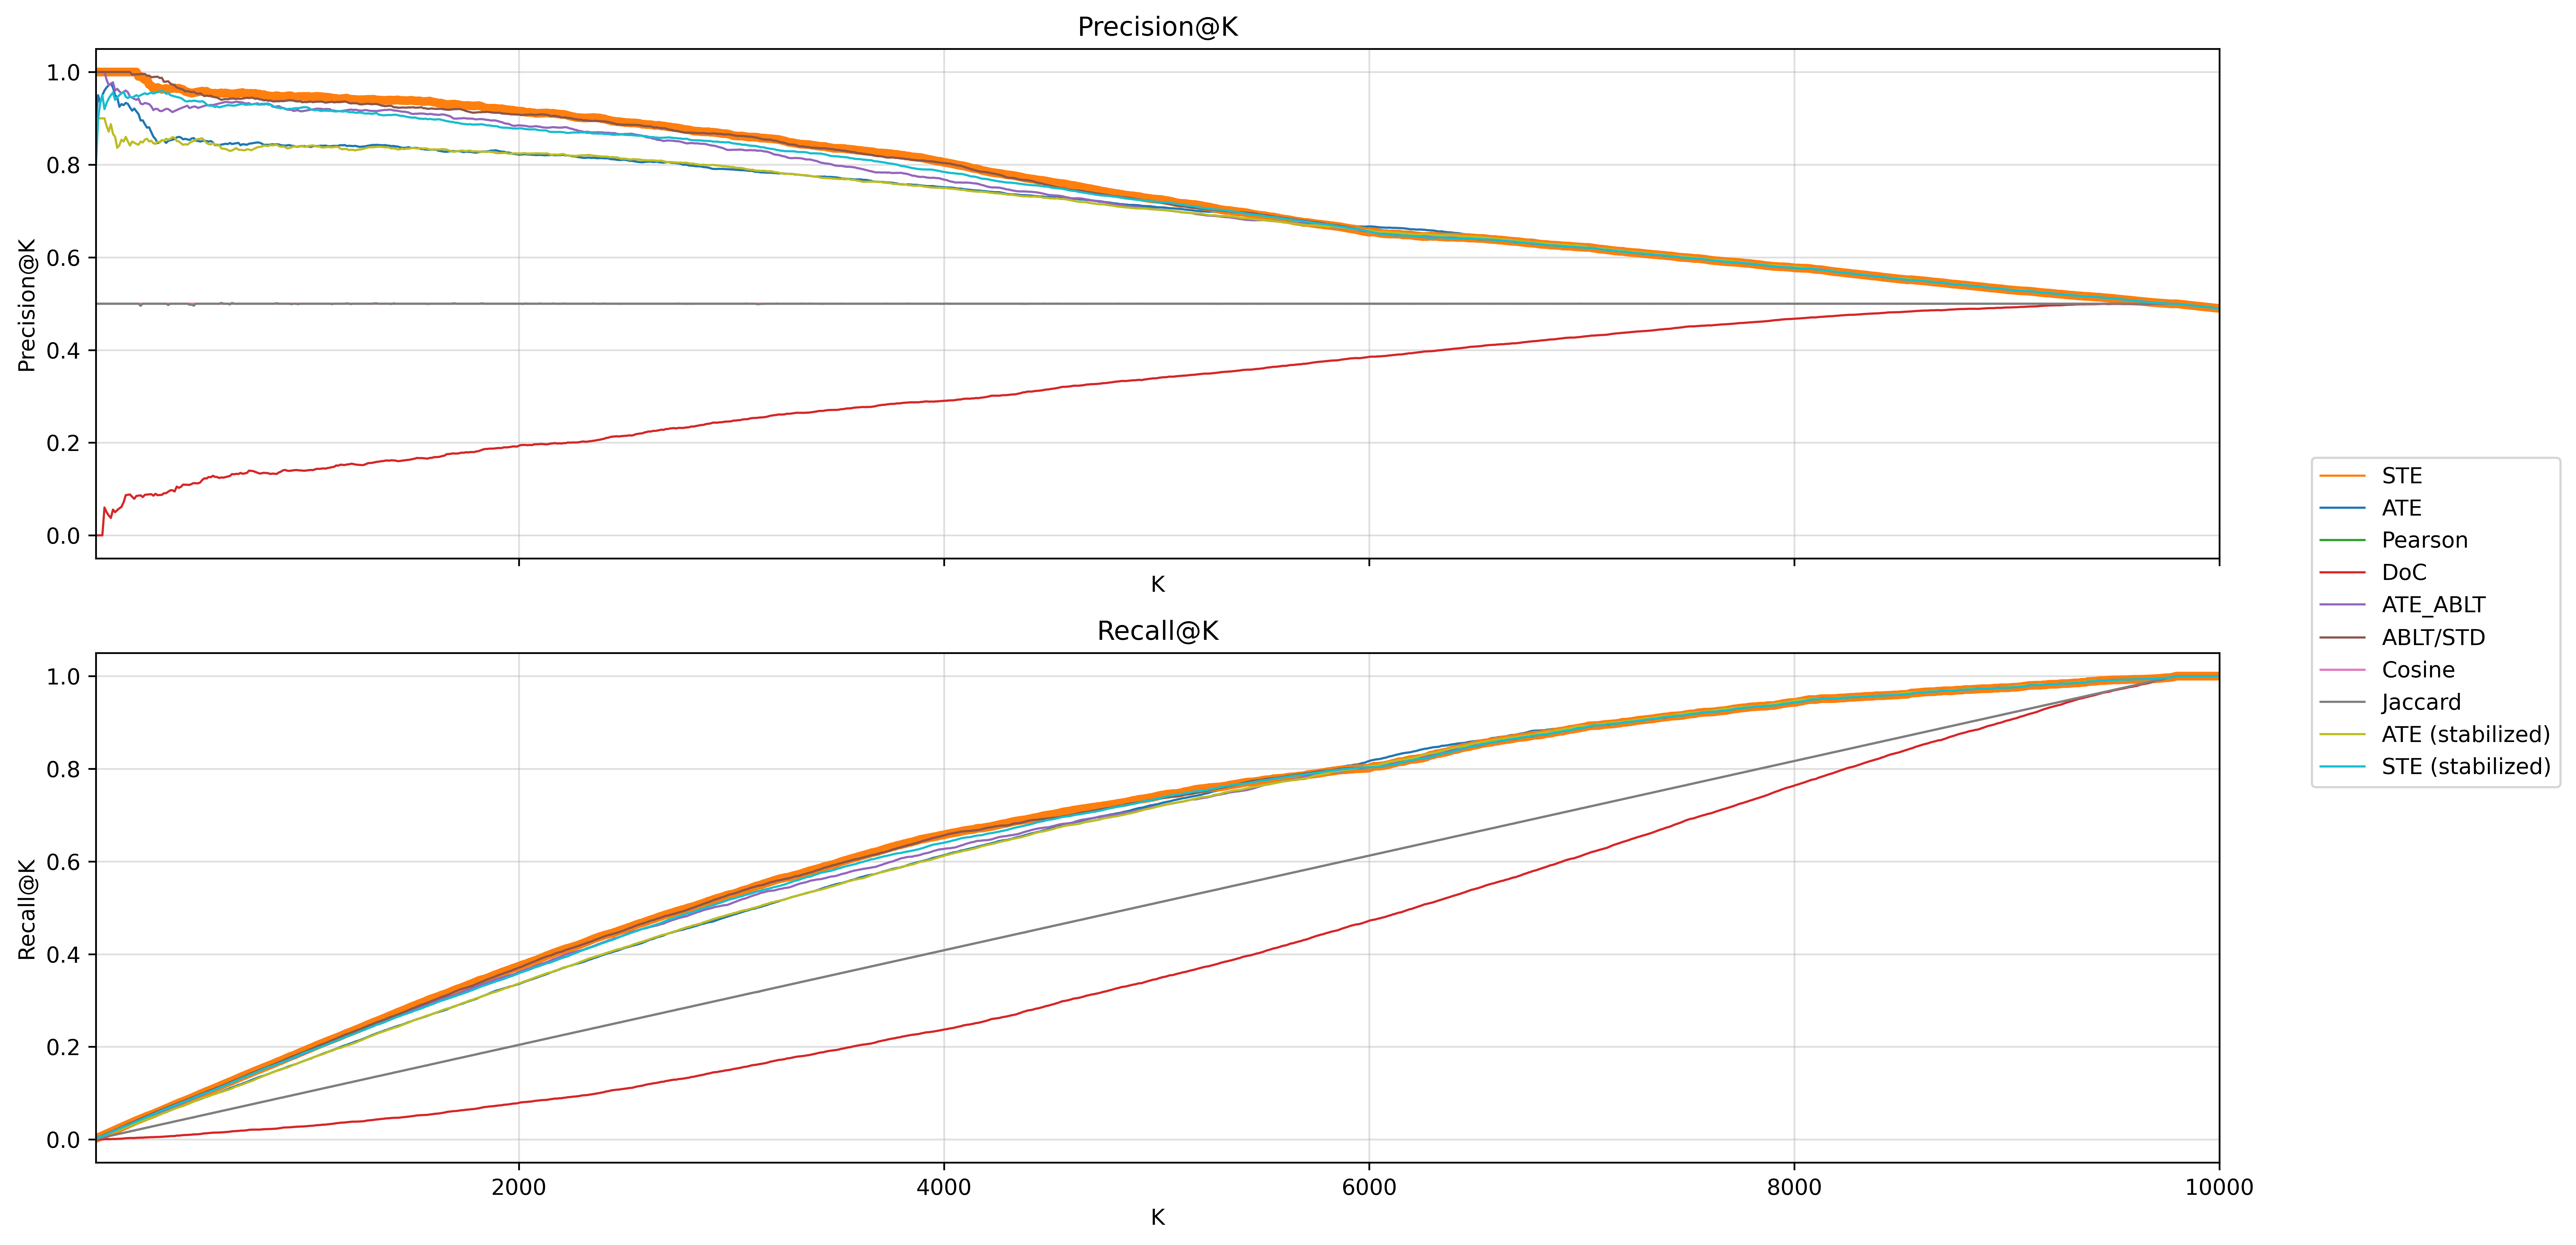

In [5]:
Ks = np.arange(10, 10001, step=10)


fig, axes = plt.subplots(2, 1, figsize=(14.5, 8), dpi=600, sharex=True)

# Ground truth
y_true = raw_results['causal_effect'] > 0
total_positives = y_true.sum()

# Store curves + mean scores
precision_curves = {}
recall_curves = {}
mean_precision = {}
mean_recall = {}

# ---- compute curves ----
for col in baselines:
    col_ser = raw_results.sort_values(
        by=col,
        ascending=False
    )['causal_effect']

    causal_link = col_ser > 0

    precision_vals = np.array([
        causal_link[:K].sum() / K
        for K in Ks
    ])

    recall_vals = np.array([
        causal_link[:K].sum() / total_positives
        for K in Ks
    ])

    precision_curves[col] = precision_vals
    recall_curves[col] = recall_vals

    mean_precision[col] = precision_vals.mean()
    mean_recall[col] = recall_vals.mean()


# ---- select best baselines (by mean) ----
best_precision_col = max(mean_precision, key=mean_precision.get)
best_recall_col = max(mean_recall, key=mean_recall.get)


# ---- plot Precision@K ----
for col in baselines:
    axes[0].plot(
        Ks,
        precision_curves[col],
        color=color_map[col],
        linewidth=4 if col == best_precision_col else 1,
        label=col
    )


# ---- plot Recall@K ----
for col in baselines:
    axes[1].plot(
        Ks,
        recall_curves[col],
        color=color_map[col],
        linewidth=4 if col == best_recall_col else 1,
        label=col
    )


# ---- formatting ----
axes[0].set_title("Precision@K")
axes[1].set_title("Recall@K")

axes[0].set_ylabel("Precision@K")
axes[1].set_ylabel("Recall@K")

axes[0].set_xlabel("K")
axes[1].set_xlabel("K")

for ax in axes:
    ax.grid(alpha=0.4)
    ax.set_xlim([Ks[0], Ks[-1]])


# ---- shared legend ----

# swap indices 0 and 1
order = list(range(len(baselines)))
order[0], order[1] = order[1], order[0]

legend_handles = [
    Line2D(
        [0], [0],
        color=axes[0].lines[i].get_color(),
        lw=1,
        label=baselines[i]
    )
    for i in order
]

fig.legend(
    handles=legend_handles,
    labels=[baselines[i] for i in order],
    bbox_to_anchor=(1.01, 0.5),
    loc="center left"
)

plt.tight_layout()

plt.savefig(
     figures_path / 'precision_recall_at_k.jpeg',
    bbox_inches='tight'
)

plt.show()

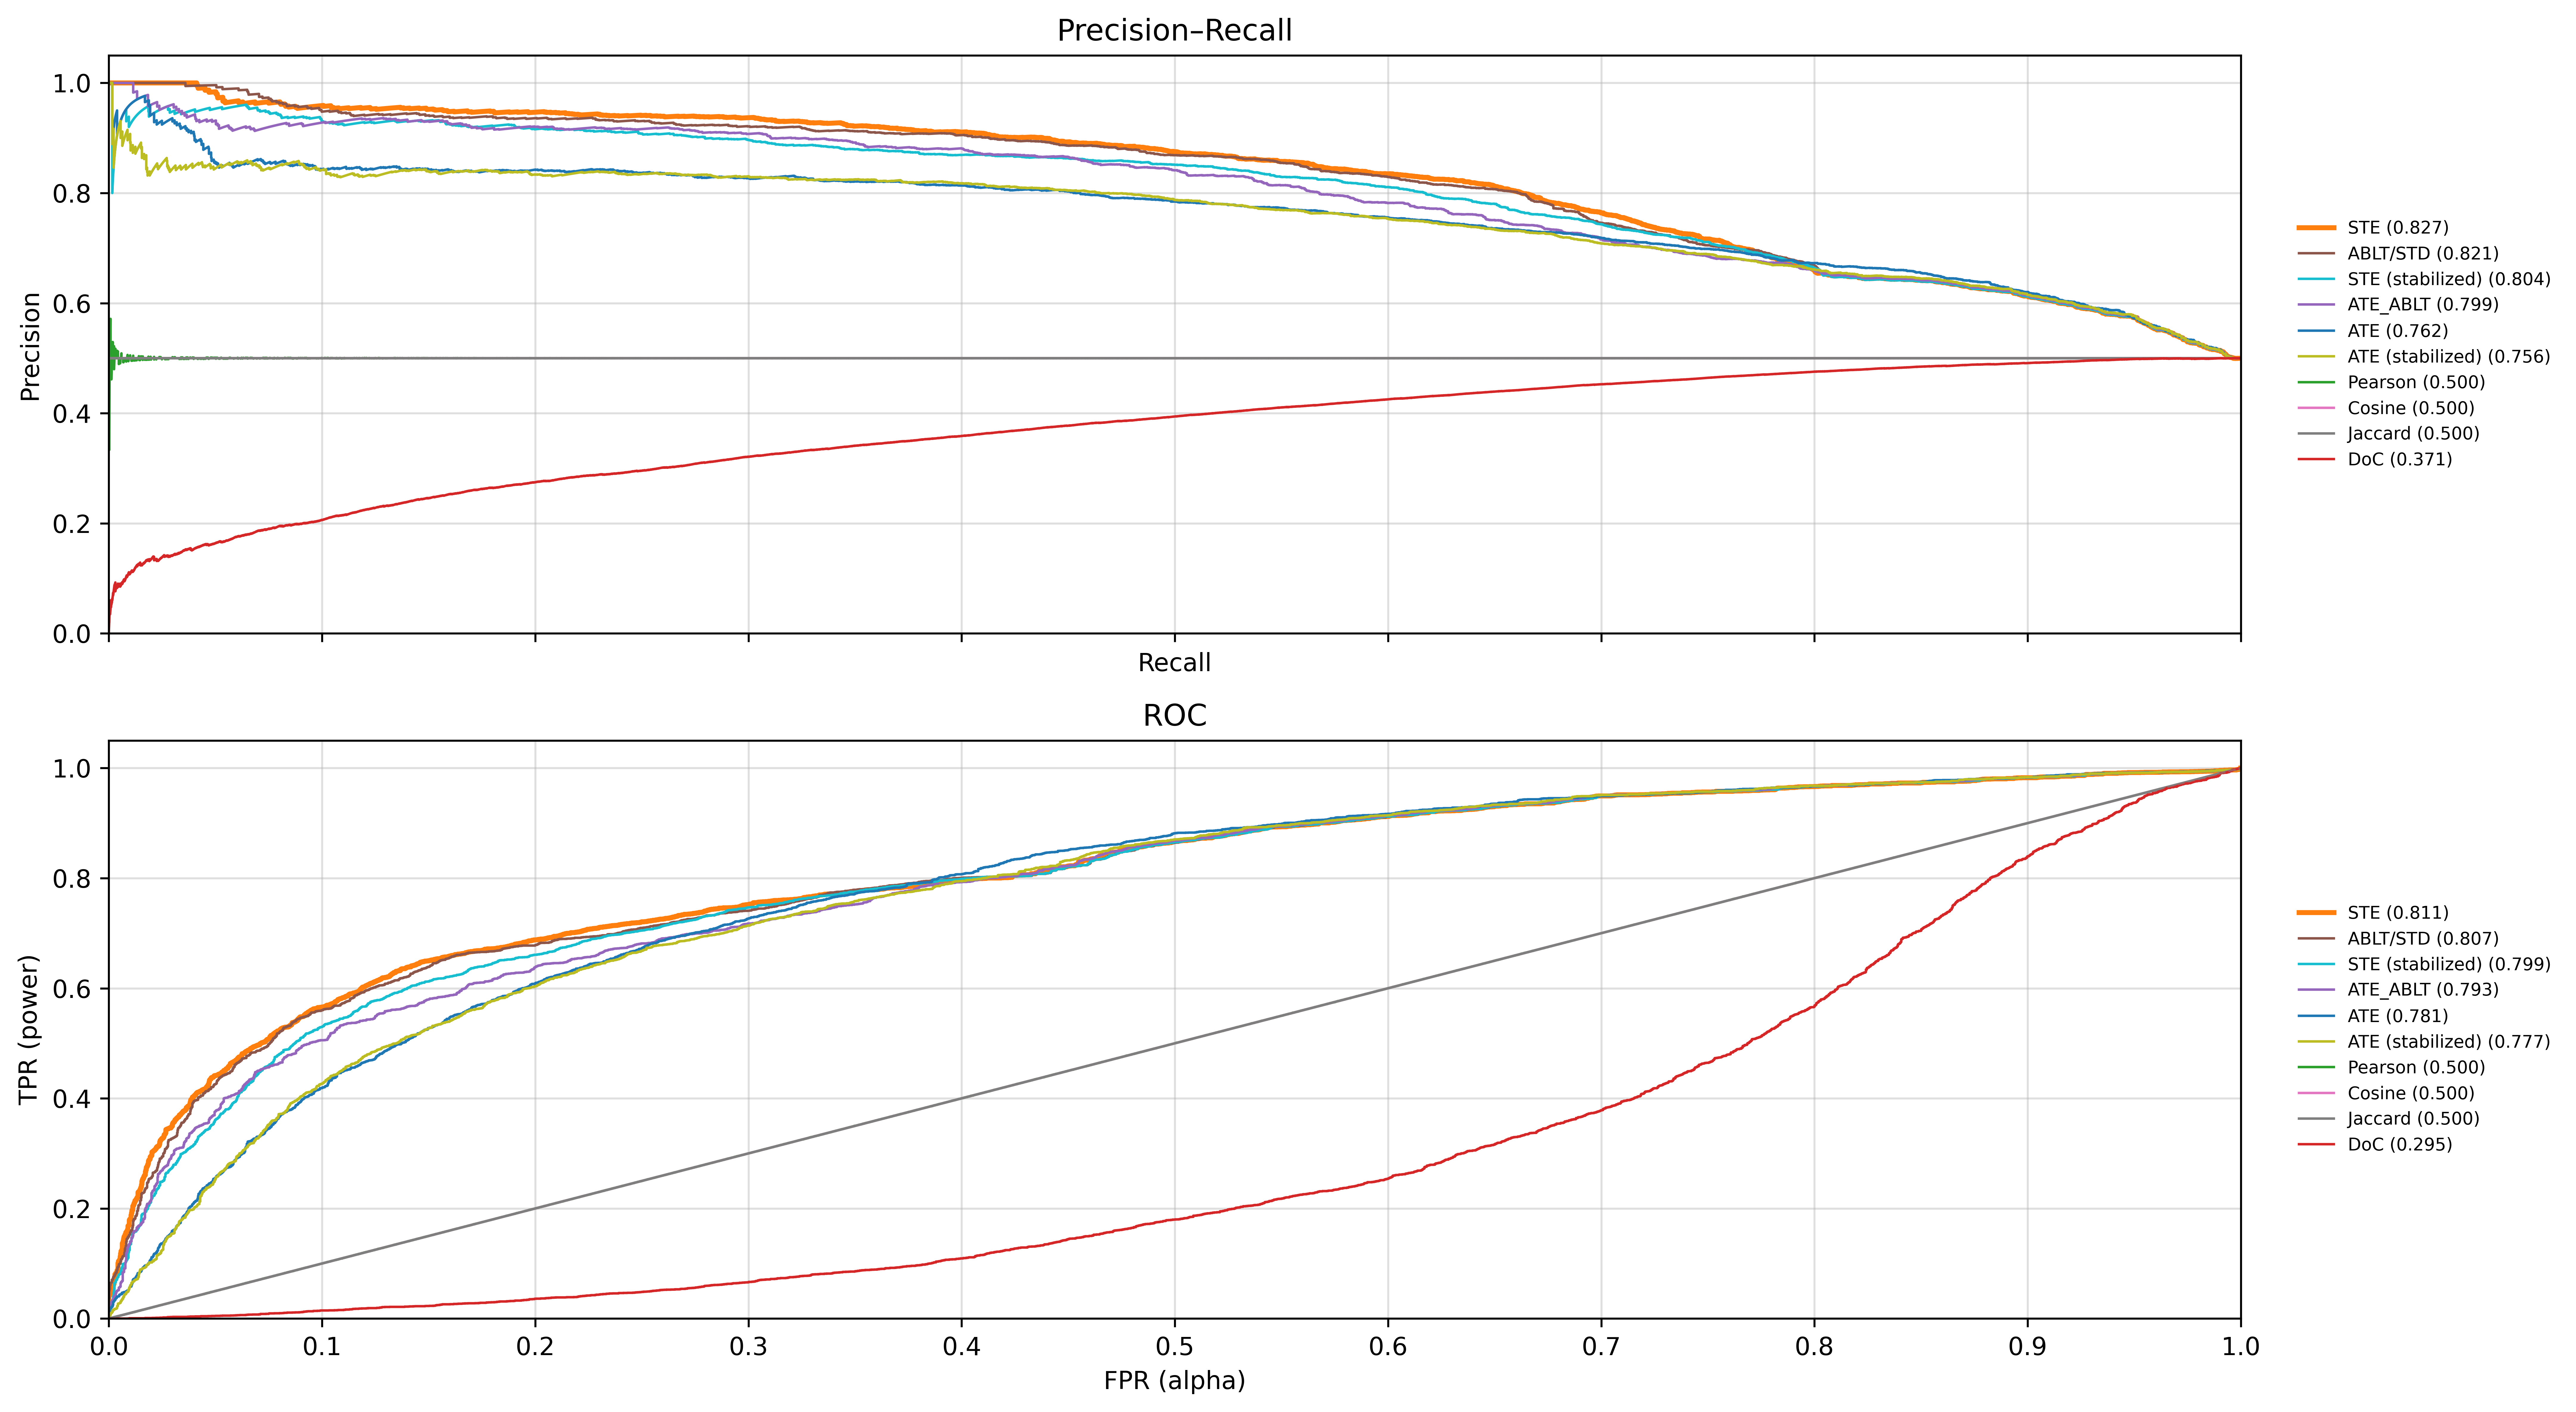

,Average Precision,ROC-AUC
ATE,76.15%,78.08%
STE,82.66%,81.06%
Pearson,50.01%,50.00%
DoC,37.13%,29.46%
ATE_ABLT,79.90%,79.32%
ABLT/STD,82.13%,80.71%
Cosine,50.00%,50.00%
Jaccard,50.00%,50.00%
ATE (stabilized),75.56%,77.67%
STE (stabilized),80.38%,79.93%


In [6]:
summary = {col: {} for col in baselines}

fig, axes = plt.subplots(2, 1, figsize=(14.5, 8), dpi=600, sharex=True)

y_true = (raw_results['causal_effect'] > 0).astype(int).values

# --- collect curves + scores first ---
pr_data = []
roc_data = []

for col in baselines:
    y_score = raw_results[col].values

    # Precision–Recall
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    summary[col]['Average Precision'] = ap
    pr_data.append((col, recall[:-1], precision[:-1], ap))

    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)
    summary[col]['ROC-AUC'] = auc
    roc_data.append((col, fpr, tpr, auc))

# --- sort by score ---
pr_data.sort(key=lambda x: x[3], reverse=True)    # by AP
roc_data.sort(key=lambda x: x[3], reverse=True)  # by AUC

# --- plot PR ---
for rank, (col, recall, precision, ap) in enumerate(pr_data):
    axes[0].plot(
        recall,
        precision,
        lw=2 if rank == 0 else 1,
        color=color_map[col],
        label=f"{col} ({ap:.3f})"
    )

# --- plot ROC ---
for rank, (col, fpr, tpr, auc) in enumerate(roc_data):
    axes[1].plot(
        fpr,
        tpr,
        lw=2 if rank == 0 else 1,
        color=color_map[col],
        label=f"{col} ({auc:.3f})"
    )

axes[1].plot(
    [0, 1], [0, 1],
    ls="--",
    lw=0.8,
    color="grey",
    alpha=0.6
)

# ---- Titles & formatting ----
axes[0].set_title("Precision–Recall")
axes[1].set_title("ROC")

axes[0].set_ylabel("Precision")
axes[1].set_ylabel("TPR (power)")

axes[0].set_xlabel("Recall")
axes[1].set_xlabel("FPR (alpha)")

for j in range(2):
    axes[j].set_xlim([0, 1])
    axes[j].set_ylim([0, None])
    axes[j].set_xticks(np.arange(0, 1.1, 0.1))
    axes[j].grid(alpha=0.4)

    if auxiliary:
        axes[j].legend(
            fontsize=7,
            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            frameon=False
        )
    else:
        axes[j].legend(
            fontsize=7,
            loc='upper right' if j == 0 else 'lower right',
            frameon=False
        )


plt.tight_layout()
plt.savefig(
    figures_path / 'pr_roc_curves.jpeg',
    bbox_inches='tight'
)
plt.show()


# ---- summary table ----
summary_df = pd.DataFrame(summary).T
summary_df = summary_df[['Average Precision', 'ROC-AUC']]
summary_df = summary_df.map(lambda x: f"{x:.2%}")

display(summary_df)

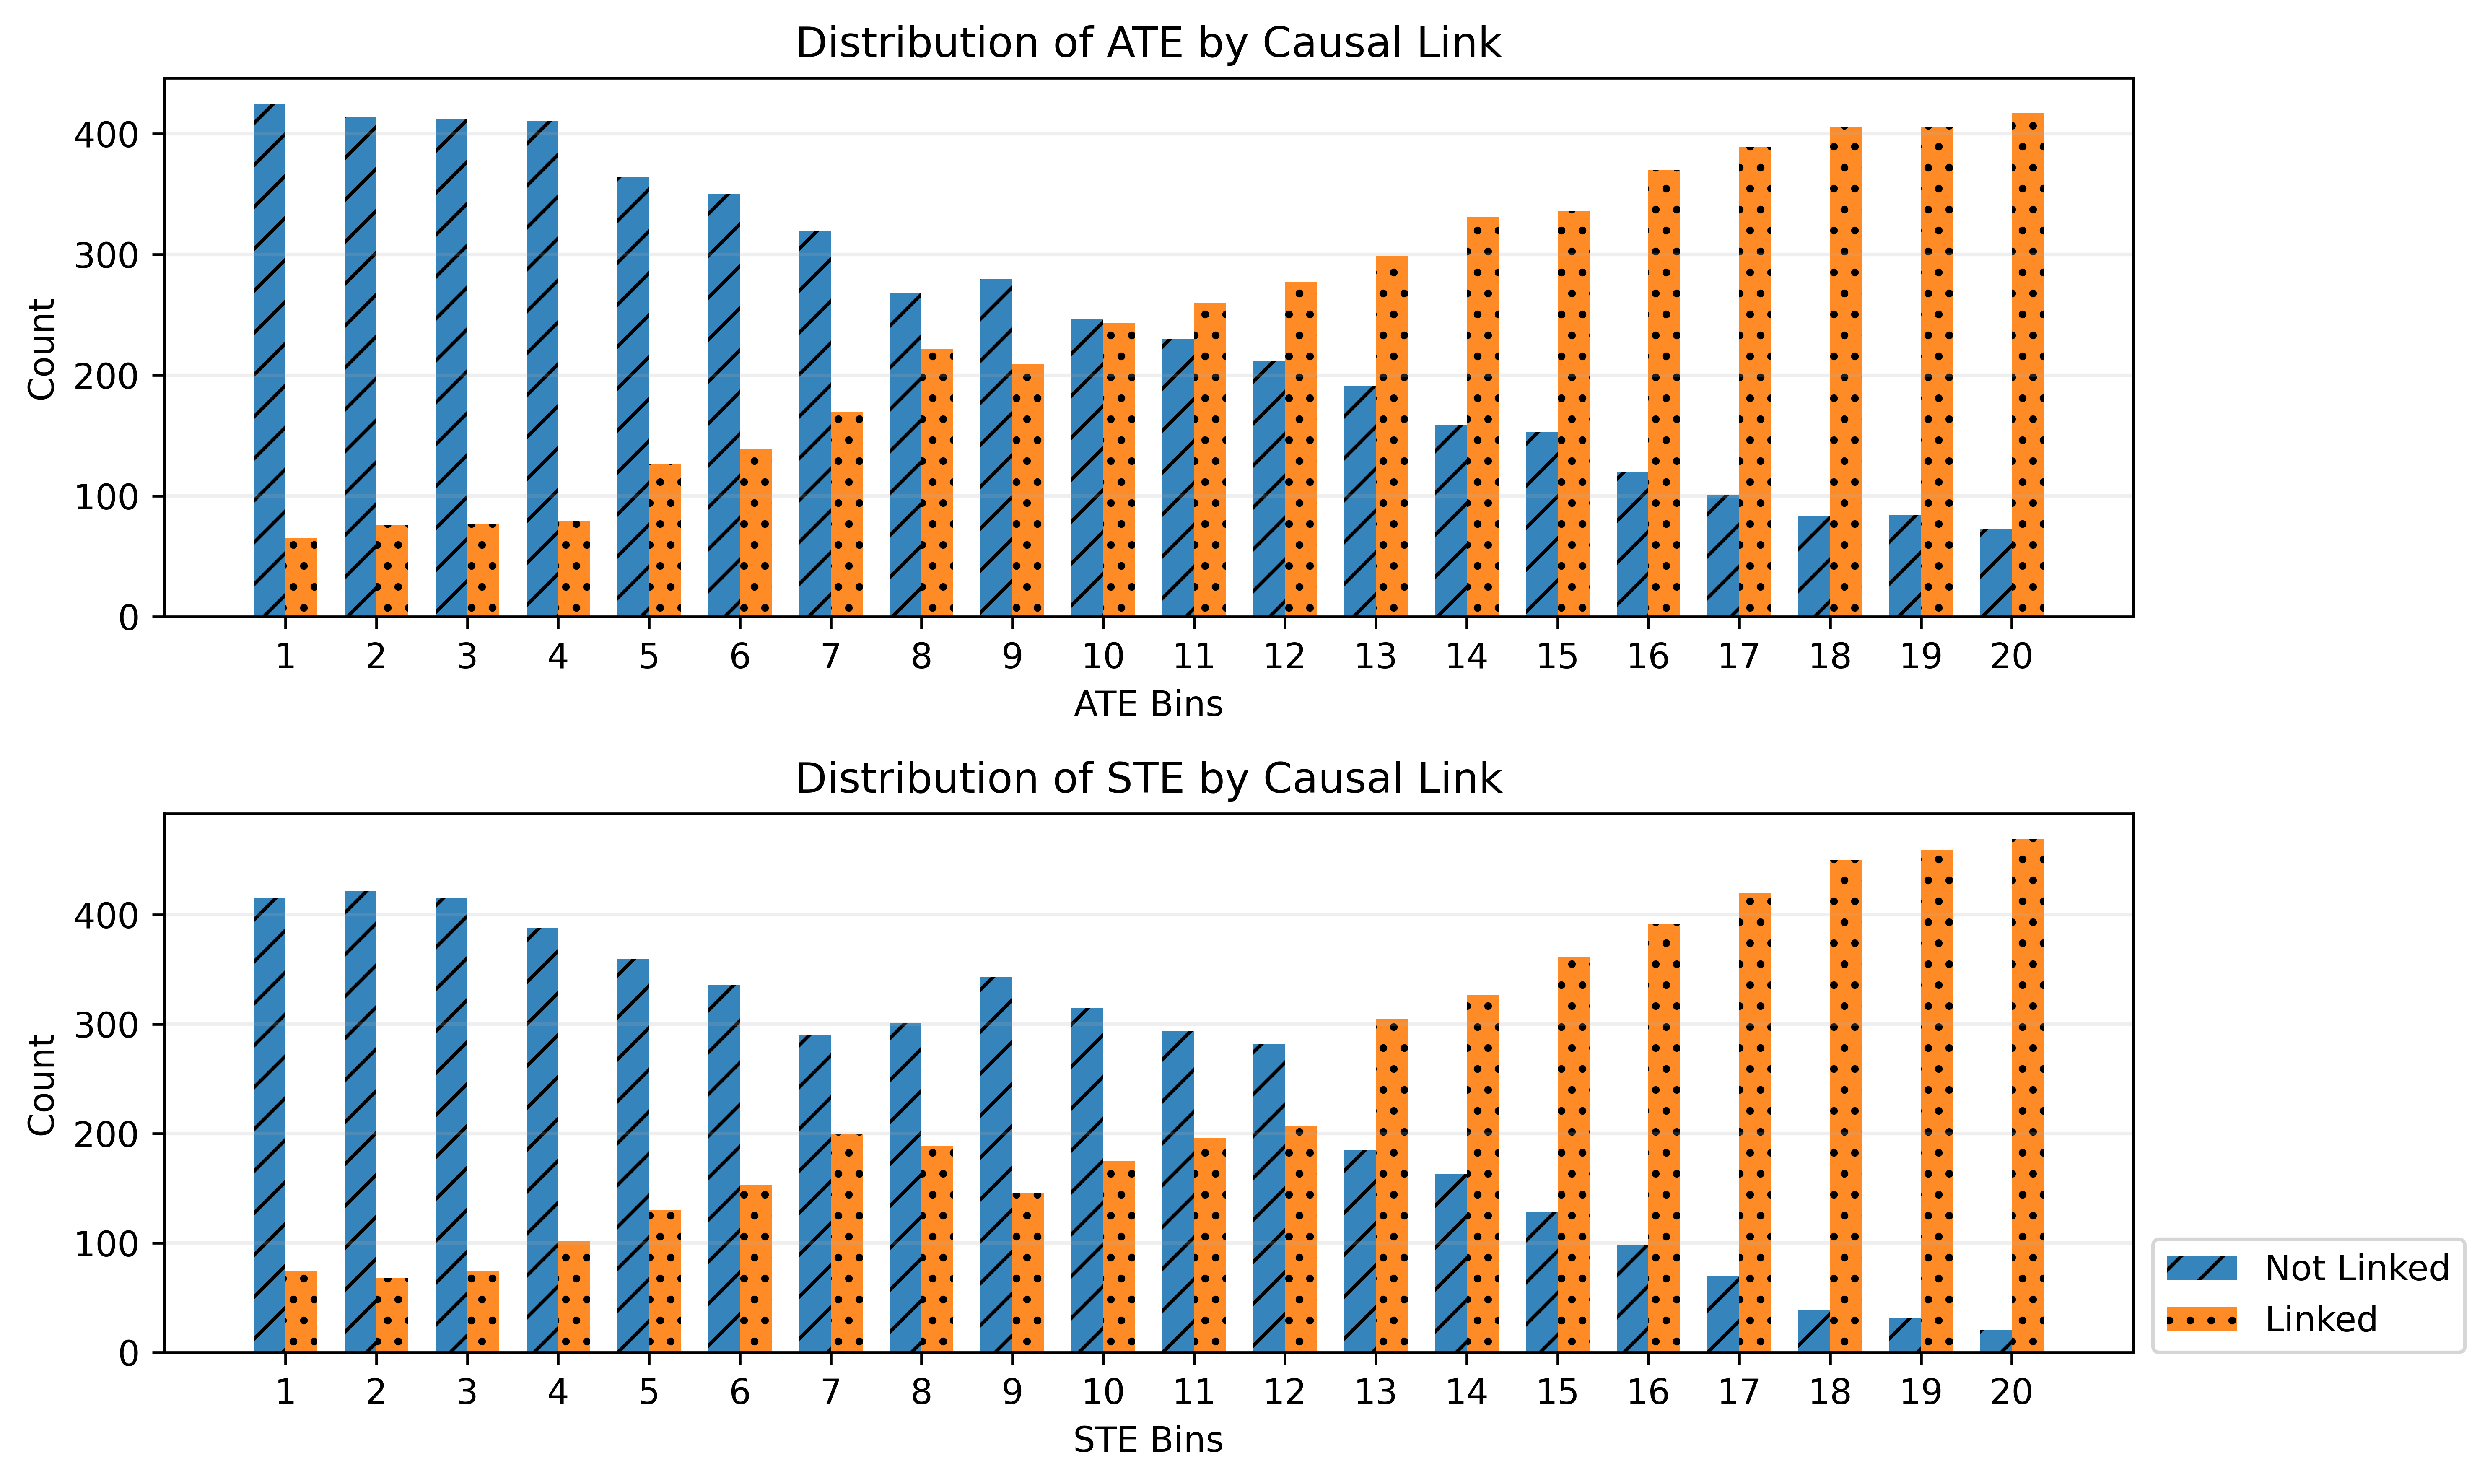

In [7]:
num_bins = 20
w = 0.35
hatches = ['//', '..']

fig, axes = plt.subplots(2, 1, figsize=(10, 6), dpi=600)

for ax, metric in zip(axes, ["ATE", "STE"]):

    # Quantile bins for the current metric
    bins = np.quantile(
        raw_results[metric].values,
        np.arange(0, 1, 1 / num_bins)
    )

    df = raw_results[[metric, 'causal_effect']].copy()
    df['metric_bin'] = np.digitize(df[metric], bins) - 1

    for link in [0, 1]:
        subset = df[(df['causal_effect'] > 0) == bool(link)]
        counts = subset['metric_bin'].value_counts().sort_index()

        ax.bar(
            counts.index + (link - 0.5) * w,
            counts.values,
            width=w,
            alpha=0.9,
            hatch=hatches[link],
            label='Linked' if link == 1 else 'Not Linked'
        )

    ax.set_xticks(range(num_bins))
    ax.set_xticklabels(range(1, num_bins + 1))
    # ax.set_yticks(range(0, 351, 50))
    ax.set_ylim(0)
    ax.set_xlabel(f'{metric} Bins')
    ax.set_ylabel('Count')
    ax.set_title(f'Distribution of {metric} by Causal Link')

    # ax.set_yscale('log')
    ax.grid(axis='y', which='major', alpha=0.2, linewidth=1)

plt.legend(loc=(1.01, 0))
plt.tight_layout()
plt.savefig(
    base_artifacts / 'Figures' / 'sequels' / 'Binned Distribution.jpeg',
    bbox_inches='tight')
plt.show()